## 2.3.1 Experiment Objective

The objective of hyperparameter experimentation is to understand how different learning rates, optimizers, and batch sizes affect CNN performance. The CIFAR-10 dataset and CNN architecture are kept consistent across experiments. Validation accuracy and training time are recorded to compare the results.

## 2.3.2 Prepare Dataset for Experiments

A fixed subset of CIFAR-10 is used to make experiments manageable in Google Colab. The same training and validation samples are used across all experiments.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import time

from torch.utils.data import DataLoader, Subset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

experiment_dataset = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

# Fixed subset for faster experiments
subset_indices = list(range(12000))
experiment_subset = Subset(experiment_dataset, subset_indices)

train_size = 10000
val_size = 2000

train_subset, val_subset = random_split(
    experiment_subset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Experiment training samples:", len(train_subset))
print("Validation samples:", len(val_subset))

Using device: cuda


100%|██████████| 170M/170M [36:55<00:00, 77.0kB/s]


Experiment training samples: 10000
Validation samples: 2000


## 2.3.3 Define CNN Architecture

The same CNN architecture is used for all experiments. Only the selected hyperparameters are changed to make the comparison meaningful.

In [2]:
class CNNClassifier(nn.Module):

    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 2.3.4 Configure Experiments

A baseline configuration is defined, followed by experiments that change the learning rate, optimizer, and batch size. The number of epochs is kept fixed to compare the selected hyperparameters.

In [3]:
experiments = [
    {
        "run_id": "Baseline",
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs": 3
    },
    {
        "run_id": "LR_0.0005",
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 64,
        "epochs": 3
    },
    {
        "run_id": "LR_0.005",
        "optimizer": "Adam",
        "learning_rate": 0.005,
        "batch_size": 64,
        "epochs": 3
    },
    {
        "run_id": "SGD_Optimizer",
        "optimizer": "SGD",
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs": 3
    },
    {
        "run_id": "Batch_32",
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 3
    },
    {
        "run_id": "Batch_128",
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 128,
        "epochs": 3
    }
]

print("Total experiments:", len(experiments))

Total experiments: 6


## 2.3.5 Run Hyperparameter Experiments

Each experiment trains a newly initialized CNN using its assigned hyperparameters. Training loss, validation accuracy, and training time are recorded for comparison.

In [4]:
criterion = nn.CrossEntropyLoss()
results = []

for config in experiments:

    print("\nRunning:", config["run_id"])

    # Same data split; batch size varies by experiment
    train_loader_exp = DataLoader(
        train_subset,
        batch_size=config["batch_size"],
        shuffle=True
    )

    val_loader_exp = DataLoader(
        val_subset,
        batch_size=128,
        shuffle=False
    )

    # Fresh model for each run
    model_exp = CNNClassifier().to(device)

    if config["optimizer"] == "Adam":
        optimizer_exp = optim.Adam(
            model_exp.parameters(),
            lr=config["learning_rate"]
        )
    else:
        optimizer_exp = optim.SGD(
            model_exp.parameters(),
            lr=config["learning_rate"]
        )

    start_time = time.time()

    for epoch in range(config["epochs"]):

        model_exp.train()
        running_loss = 0.0

        for images, labels in train_loader_exp:
            images = images.to(device)
            labels = labels.to(device)

            optimizer_exp.zero_grad()

            outputs = model_exp(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_exp.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader_exp)

        print(
            f"Epoch [{epoch+1}/{config['epochs']}] "
            f"Training Loss: {epoch_loss:.4f}"
        )

    # Validation evaluation
    model_exp.eval()
    correct = 0
    total = 0
    val_loss_total = 0.0

    with torch.no_grad():
        for images, labels in val_loader_exp:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_exp(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item()

            predictions = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_accuracy = 100 * correct / total
    avg_val_loss = val_loss_total / len(val_loader_exp)
    elapsed_time = time.time() - start_time

    results.append({
        "Run ID": config["run_id"],
        "Optimizer": config["optimizer"],
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Epochs": config["epochs"],
        "Final Training Loss": round(epoch_loss, 4),
        "Validation Loss": round(avg_val_loss, 4),
        "Validation Accuracy (%)": round(val_accuracy, 2),
        "Training Time (seconds)": round(elapsed_time, 2)
    })

    print(f"Validation Accuracy: {val_accuracy:.2f}%")
    print(f"Training Time: {elapsed_time:.2f} seconds")

    del model_exp
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll experiments completed.")


Running: Baseline
Epoch [1/3] Training Loss: 1.8317
Epoch [2/3] Training Loss: 1.4855
Epoch [3/3] Training Loss: 1.2892
Validation Accuracy: 53.85%
Training Time: 11.29 seconds

Running: LR_0.0005
Epoch [1/3] Training Loss: 1.8857
Epoch [2/3] Training Loss: 1.5442
Epoch [3/3] Training Loss: 1.4020
Validation Accuracy: 48.75%
Training Time: 10.01 seconds

Running: LR_0.005
Epoch [1/3] Training Loss: 1.8320
Epoch [2/3] Training Loss: 1.4734
Epoch [3/3] Training Loss: 1.3008
Validation Accuracy: 52.30%
Training Time: 11.01 seconds

Running: SGD_Optimizer
Epoch [1/3] Training Loss: 2.3030
Epoch [2/3] Training Loss: 2.3022
Epoch [3/3] Training Loss: 2.3013
Validation Accuracy: 14.75%
Training Time: 9.91 seconds

Running: Batch_32
Epoch [1/3] Training Loss: 1.7756
Epoch [2/3] Training Loss: 1.3979
Epoch [3/3] Training Loss: 1.2060
Validation Accuracy: 55.15%
Training Time: 10.42 seconds

Running: Batch_128
Epoch [1/3] Training Loss: 1.9047
Epoch [2/3] Training Loss: 1.5743
Epoch [3/3] Train

## 2.3.6 Compare Experiment Results

The experiment results are organized into a comparison table. Validation accuracy, validation loss, and training time are used to analyze the effect of each hyperparameter.

In [5]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Validation Accuracy (%)",
    ascending=False
)

display(results_df)

results_df.to_csv(
    "hyperparameter_experiment_results.csv",
    index=False
)

print("Experiment results saved successfully.")

,Run ID,Optimizer,Learning Rate,Batch Size,Epochs,Final Training Loss,Validation Loss,Validation Accuracy (%),Training Time (seconds)
4,Batch_32,Adam,0.0010,32,3,1.2060,1.2087,55.15,10.42
0,Baseline,Adam,0.0010,64,3,1.2892,1.2700,53.85,11.29
2,LR_0.005,Adam,0.0050,64,3,1.3008,1.3241,52.30,11.01
1,LR_0.0005,Adam,0.0005,64,3,1.4020,1.3890,48.75,10.01
5,Batch_128,Adam,0.0010,128,3,1.3979,1.4021,48.00,11.30
3,SGD_Optimizer,SGD,0.0010,64,3,2.3013,2.3007,14.75,9.91


Experiment results saved successfully.


## 2.3.7 Experiment Performance Visualization

A bar chart is used to compare validation accuracy across the different hyperparameter configurations.

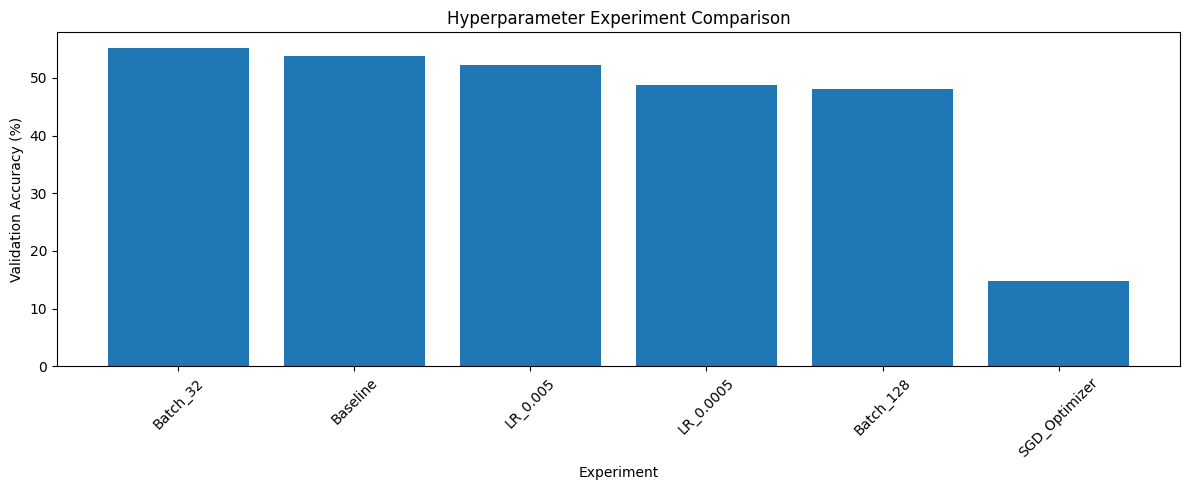

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.bar(
    results_df["Run ID"],
    results_df["Validation Accuracy (%)"]
)

plt.xlabel("Experiment")
plt.ylabel("Validation Accuracy (%)")
plt.title("Hyperparameter Experiment Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.3.8 Best Configuration and Findings

The experiment with the highest validation accuracy is identified. Its hyperparameter settings are reviewed alongside validation loss and training time. The result is treated as the best configuration among the tested experiments, not as a guarantee of best possible performance.

In [8]:
best_result = results_df.iloc[0]

print("Best Configuration (by validation accuracy)")
print("--------------------------------------------")
print("Run ID:", best_result["Run ID"])
print("Optimizer:", best_result["Optimizer"])
print("Learning Rate:", best_result["Learning Rate"])
print("Batch Size:", best_result["Batch Size"])
print("Epochs:", best_result["Epochs"])
print("Validation Accuracy:", best_result["Validation Accuracy (%)"], "%")
print("Validation Loss:", best_result["Validation Loss"])
print("Training Time:", best_result["Training Time (seconds)"], "seconds")

Best Configuration (by validation accuracy)
--------------------------------------------
Run ID: Batch_32
Optimizer: Adam
Learning Rate: 0.001
Batch Size: 32
Epochs: 3
Validation Accuracy: 55.15 %
Validation Loss: 1.2087
Training Time: 10.42 seconds


## 2.3.9 Conclusion

Hyperparameter experimentation was conducted on a CIFAR-10 CNN using different learning rates, optimizers, and batch sizes. The experiment results were compared using validation accuracy, validation loss, and training time. The findings help identify a suitable configuration among the tested settings.